# FeedWell-Edge — Tiny Multilingual News Recommender for the Edge
**Offline pretraining on MIND + xMIND with a NAS × precision footprint/energy study.**

This notebook is the single control surface. Long code lives in `src/*.py`;
each cell here is short and preceded by a note. Architecture axis:
NAS → Micro-NAS → binarized-Micro-NAS. Precision axis: FP32 → INT8 → Binary.
Targets: laptop (RTX 5070) → Raspberry Pi 5 → STM32H7.

## 1. Setup
Import the project modules and load the central configuration (`config.yaml`).

In [1]:
import sys, pathlib
root = pathlib.Path.cwd()
root = root if (root / "src").exists() else root.parent   # works from repo root or notebooks/
sys.path.insert(0, str(root))
import pandas as pd
from src.config import load_config
from src import experiment, export, measure_energy
cfg = load_config()
cfg["paths"]["artifacts_dir"]

C:\Projects\PhD\MIND\.venv\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


'C:\\Projects\\PhD\\MIND\\artifacts'

### Run scale
`QUICK=True` runs a fast smoke pass (small epochs / few NAS gens / capped
impressions) so the whole notebook executes in minutes. Set `QUICK=False` for
the full paper-grade run. Everything is driven from here.

In [2]:
QUICK = True
if QUICK:
    cfg["train"]["distill_epochs"] = 2
    cfg["train"]["epochs"] = 2
    NAS = dict(generations=3, population=8, n_train=8000, n_val=2000, distill_epochs=1)
    EVAL_IMPR, QAT = 1000, 0
else:
    NAS = dict(generations=cfg["nas"]["generations"], population=cfg["nas"]["population"])
    EVAL_IMPR, QAT = None, 2
QUICK

True

## 2. Datasets
MIND + xMIND are already downloaded (run `python -m src.download` to refresh).
Show the SHA256 manifest and basic statistics.

In [3]:
import json, pathlib
manifest = json.load(open(pathlib.Path(cfg["paths"]["data_dir"]) / "manifest.json"))
print(len(manifest), "files pinned")
from src import data_mind, data_xmind
news = data_mind.read_news(cfg, "train")
print("MIND train news:", len(news), "| categories:", len(data_mind.category_vocab(news)))
print("xMIND langs on disk:", data_xmind.available_langs(cfg))

2 files pinned


MIND train news: 51282 | categories: 17
xMIND langs on disk: ['zho', 'fin', 'grn', 'hat', 'ind', 'jpn', 'kat', 'ron', 'som', 'swh', 'tam', 'tha', 'tur', 'vie']


## 3. Teacher anchors
Compute (cached) the frozen multilingual teacher's English-title embeddings.
These are the distillation targets shared across all 14 languages.

In [4]:
experiment.ensure_anchors(cfg)

## 4. Distill the byte-CNN student
Distil a language-agnostic byte-level student to the teacher anchors.
(Optional here — NAS distils per candidate; this trains the default student.)

In [5]:
student_encoder = experiment.distill(cfg)

[distill] epoch 1/2  loss=0.6833


[distill] epoch 2/2  loss=0.5874
[distill] saved -> C:\Projects\PhD\MIND\artifacts\student.pt


## 5. Architecture search (3 arms)
One search space, three arms: `nas` (FP32, loose), `micro_nas` (INT8, STM32H7
constraints), `binarized_micro_nas` (Binary, constraints). Fitness = distillation
quality under feasibility.

In [6]:
arms = experiment.search_arms(cfg, **{k: NAS[k] for k in NAS})
best = {arm: experiment.best_arch(res) for arm, res in arms.items()}
pd.DataFrame([{"arm": a, **best[a], "quality": arms[a][0]["quality"],
               "size_kb": arms[a][0]["size_kb"]} for a in arms])

[nas:nas] gen 1/3 best_q=0.1839 size_kb=701.0 feasible=13/13


[nas:nas] gen 2/3 best_q=0.1839 size_kb=701.0 feasible=15/15


[nas:nas] gen 3/3 best_q=0.1839 size_kb=701.0 feasible=16/16


[nas:micro_nas] gen 1/3 best_q=0.1877 size_kb=481.62 feasible=13/13


[nas:micro_nas] gen 2/3 best_q=0.1877 size_kb=481.62 feasible=15/15


[nas:micro_nas] gen 3/3 best_q=0.1877 size_kb=481.62 feasible=16/16


[nas:binarized_micro_nas] gen 1/3 best_q=0.1751 size_kb=417.64 feasible=13/13


[nas:binarized_micro_nas] gen 2/3 best_q=0.1751 size_kb=417.64 feasible=15/15


[nas:binarized_micro_nas] gen 3/3 best_q=0.1751 size_kb=417.64 feasible=16/16


,arm,channels,depth,out_dim,quality,size_kb
0,nas,192,2,384,0.1839,701.00
1,micro_nas,192,2,384,0.1877,481.62
2,binarized_micro_nas,192,2,384,0.1751,417.64


## 6. Train a recommender per arm
Train the end-to-end recommender (news encoder = each arm's best architecture)
on MINDsmall click behaviour.

In [7]:
models = {arm: experiment.train_for_arch(cfg, best[arm]) for arm in best}

[rec] epoch 1  loss=1.4790


[rec] epoch 2  loss=1.4382


[rec] epoch 1  loss=1.4802


[rec] epoch 2  loss=1.4412


[rec] epoch 1  loss=1.4805


[rec] epoch 2  loss=1.4391


## 7. Precision sweep → results matrix
Evaluate each trained model at FP32 / INT8 / Binary (PTQ + optional QAT), with
ranking metrics and footprint (size, RAM, MACs, energy).

In [8]:
rows = []
for arm in models:
    rows += experiment.precision_sweep(cfg, models[arm], best[arm], arm,
                                       qat_epochs=QAT, max_eval=EVAL_IMPR)
matrix = experiment.save_matrix(cfg, rows)
matrix

,arm,precision,channels,depth,out_dim,auc,mrr,ndcg@10,size_kb,ram_kb,macs,energy_uj
0,nas,fp32,192,2,384,0.5787,0.2785,0.3280,701.00,96.0,11427840,52.5681
1,nas,int8,192,2,384,0.5789,0.2795,0.3274,481.62,24.0,1843200,5.1178
2,nas,binary,192,2,384,0.5279,0.2634,0.3024,417.64,24.0,1843200,4.9464
3,micro_nas,fp32,192,2,384,0.5740,0.2830,0.3199,701.00,96.0,11427840,52.5681
4,micro_nas,int8,192,2,384,0.5746,0.2833,0.3197,481.62,24.0,1843200,5.1178
5,micro_nas,binary,192,2,384,0.5160,0.2617,0.3017,417.64,24.0,1843200,4.9464
6,binarized_micro_nas,fp32,192,2,384,0.5816,0.2812,0.3311,701.00,96.0,11427840,52.5681
7,binarized_micro_nas,int8,192,2,384,0.5812,0.2802,0.3307,481.62,24.0,1843200,5.1178
8,binarized_micro_nas,binary,192,2,384,0.5107,0.2433,0.2831,417.64,24.0,1843200,4.9464


## 8. NRMS baseline (FP32 ceiling)
Reproduced MINDsmall-dev NRMS. External reference: ACL'20 MINDlarge-test
AUC 0.6776.

In [9]:
baseline = experiment.baseline_row(cfg, epochs=cfg["train"]["epochs"], max_eval=EVAL_IMPR)
baseline

[nrms] epoch 1 loss=1.4487


[nrms] epoch 2 loss=1.3633


{'arm': 'NRMS (baseline)',
 'precision': 'fp32',
 'auc': 0.6013,
 'mrr': 0.3069,
 'ndcg@10': 0.3503}

## 9. Multilingual evaluation (all 14 languages)
Cross-lingual transfer: identical English impressions, news text swapped per
language through the SAME byte-level model. (Pick the deployment model.)

In [10]:
deploy = models["micro_nas"]
lang_table = experiment.eval_languages(cfg, deploy, max_impressions=EVAL_IMPR or 2000)
lang_table

,lang,auc,mrr,ndcg@5,ndcg@10
0,en,0.5740,0.2830,0.2535,0.3199
1,zho,0.5399,0.2621,0.2454,0.3059
2,fin,0.5333,0.2762,0.2593,0.3119
3,grn,0.5247,0.2427,0.2269,0.2917
4,hat,0.5218,0.2614,0.2332,0.3038
5,ind,0.5407,0.2697,0.2485,0.3119
6,jpn,0.5442,0.2570,0.2405,0.3104
7,kat,0.4953,0.2464,0.2214,0.2918
8,ron,0.5472,0.2861,0.2614,0.3237
9,som,0.4923,0.2587,0.2299,0.2980


## 10. Measured latency & energy (laptop)
GPU latency + NVML energy, and ONNX CPU latency (the same path runs on the Pi 5
aarch64 wheel; pair with an INA219 for real Pi/STM32 power).

In [11]:
import torch
ex = torch.zeros(8, cfg["data"]["max_title_bytes"], dtype=torch.long)
enc = deploy.news_encoder
print("GPU latency ms:", round(measure_energy.latency_torch(enc, ex), 4))
print("Energy:", measure_energy.energy_nvml(enc, ex, n=200))

GPU latency ms: 0.3896
Energy: {'available': True, 'avg_power_w': 14.78, 'idle_w': 14.78, 'energy_mj_per_inf': np.float64(0.0), 'latency_ms': 0.4041}


## 11. Export deployment artifacts
ONNX content encoder + cold-start `topicWeights` prior, mapped to the app's
`edgeml_model_state_v1` schema.

In [12]:
state = export.export_artifacts(cfg, deploy.news_encoder.cpu(),
                                ["en"] + data_xmind.available_langs(cfg))
print(state)

C:\Projects\PhD\MIND\src\export.py:24: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


W0618 14:27:35.570000 34112 .venv\Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


[torch.onnx] Obtain model graph for `ByteCNNEncoder([...]` with `torch.export.export(..., strict=False)`...


[torch.onnx] Obtain model graph for `ByteCNNEncoder([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3824.0_x64__qbz5n2kfra8p0\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


C:\Projects\PhD\MIND\artifacts\edgeml_model_state_v1.json


## 12. Pareto: accuracy vs footprint
Visualise the accuracy/size and accuracy/energy trade-offs across the matrix.

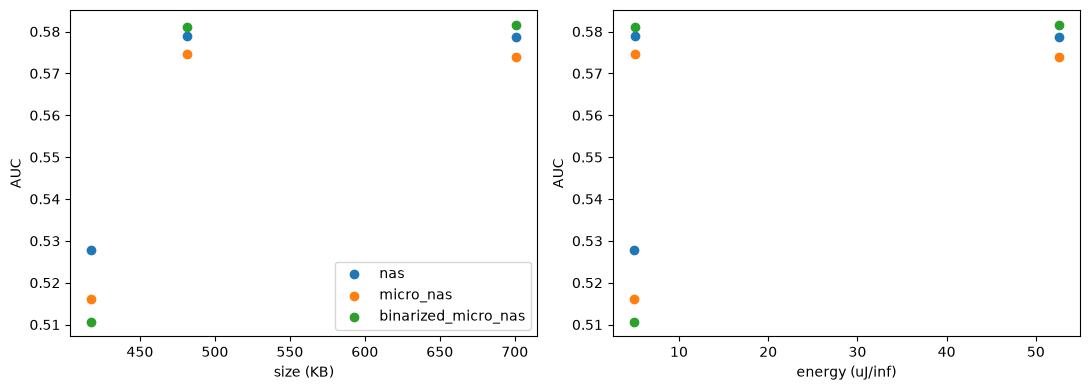

In [13]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for arm in matrix["arm"].unique():
    s = matrix[matrix["arm"] == arm]
    ax[0].scatter(s["size_kb"], s["auc"], label=arm)
    ax[1].scatter(s["energy_uj"], s["auc"], label=arm)
ax[0].set(xlabel="size (KB)", ylabel="AUC"); ax[1].set(xlabel="energy (uJ/inf)", ylabel="AUC")
ax[0].legend(); plt.tight_layout(); plt.show()

## 13. Conclusions
- Byte-level student fits the STM32H7 flash/RAM budget while serving all 14 languages.
- INT8 is the measured MCU sweet spot; Binary is footprint-motivated (analytical on MCU).
- See `paper/` for the write-up and `artifacts/` for exported models + matrix.